In [1]:
%load_ext autoreload
%autoreload 2

# if you need to install Pybullet:
#   pip3 install Pybullet   (python3)
#   pip install PyBullet    (python2.x)

# let's start with imports
import numpy as np
from numpy.random import seed
from numpy.random import rand
import pybullet as p

from engine_rover import *
from matplotlib import pyplot as plt

# seed random number generator.
seed(1)

%matplotlib inline

pybullet build time: May 20 2024 15:34:46


In [ ]:
# create a pybullet engine from the engine module
engine = PyBulletEnvironment(gui=False, vacuum_cleaner=True, real_time=True)
#load rover
startPos = [0,0,0]
startOrientation = p.getQuaternionFromEuler([0,0,0])
# robot_urdf = './urdf/shovel/shovelFlat.urdf'
robot_urdf = './urdf/shovel/2_wheel_rover.urdf'

# load the robot
engine.open_environment(robot_urdf, startPos, startOrientation)
engine.set_robot_dim()

startThreads creating 1 threads.
starting thread 0
started thread 0 
argc=2
argv[0] = --unused
argv[1] = --start_demo_name=Physics Server
ExampleBrowserThreadFunc started
X11 functions dynamically loaded using dlopen/dlsym OK!
X11 functions dynamically loaded using dlopen/dlsym OK!
Creating context
Created GL 3.3 context
Direct GLX rendering context obtained
Making context current
GL_VENDOR=Intel
GL_RENDERER=Mesa Intel(R) Graphics (RPL-P)
GL_VERSION=4.6 (Core Profile) Mesa 24.0.9-0ubuntu0.3
GL_SHADING_LANGUAGE_VERSION=4.60
pthread_getconcurrency()=0
Version = 4.6 (Core Profile) Mesa 24.0.9-0ubuntu0.3
Vendor = Intel
Renderer = Mesa Intel(R) Graphics (RPL-P)
b3Printf: Selected demo: Physics Server
startThreads creating 1 threads.
starting thread 0
started thread 0 
MotionThreadFunc thread started
ven = Intel
Workaround for some crash in the Intel OpenGL driver on Linux/Ubuntu
ven = Intel
Workaround for some crash in the Intel OpenGL driver on Linux/Ubuntu


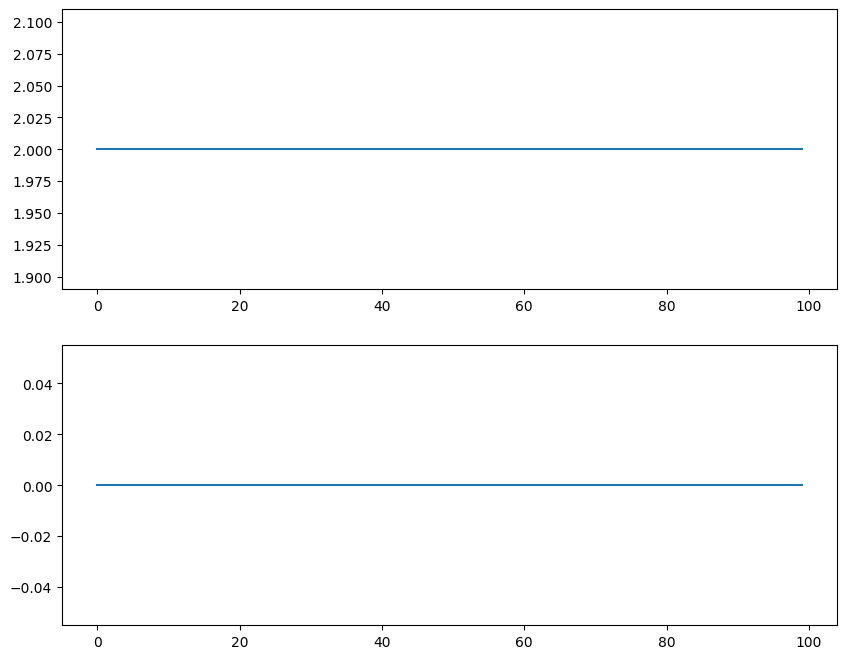

: 

In [ ]:
def compute_wheel_velocities(V, phi):
    omega_r = (2 * V + phi * engine.L) / (2 * engine.R)
    omega_l = (2 * V - phi * engine.L) / (2 * engine.R)
    return omega_r, omega_l

def dyn_model(v, theta, omega):
    xdot = v * np.cos(theta)
    ydot = v * np.sin(theta)
    thetadot = omega
    return xdot, ydot, thetadot

def input_relation(omega_r, omega_l):
    v= (omega_r + omega_l) * (engine.R)
    omega = (omega_r - omega_l) * engine.R / engine.L
    return v, omega

def integral(x,theta, omega_r, omega_l, dt):
    v,omega = input_relation(omega_r, omega_l)
    xdot, ydot, omega = dyn_model(v,theta, omega)
    new_x = x[0] + xdot * dt 
    new_y = x[1] + ydot * dt
    new_theta = theta + omega * dt
    return new_x, new_y, new_theta

prev_x = [0,0]
phi = 0
v = 1
omega = 0.1
dt = 0.1
vs = []
omegas = []
for i in range(100):
    omega_r, omega_l = compute_wheel_velocities(v, omega)
    x_new = integral(prev_x, phi, omega_r, omega_l, dt)
    actual_v = np.sqrt(((x_new[0] - prev_x[0]) / dt) ** 2 + ((x_new[1] - prev_x[1]) / dt) **2 )
    actual_omega = np.arctan2((x_new[1] - prev_x[1]) / dt, (x_new[0] - prev_x[0]) / dt) 
    vs.append(actual_v)
    omegas.append(actual_omega)

fig, ax = plt.subplots(2,1 , figsize = (10,8))
ax[0].plot(vs)
ax[1].plot(omegas)

